In [39]:
#importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [40]:
#loading the data set and having abrief overvuiew of how it looks
df = pd.read_csv("expiry_price_data.csv")
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.dtypes.value_counts())
print(df.describe())

(15000, 10)
Index(['Product_Type', 'Brand', 'Build_Quality', 'User_Lifespan',
       'Usage_Pattern', 'Expiry_Years', 'Condition', 'Original_Price',
       'Used_Duration', 'Current_Price'],
      dtype='str')
Product_Type          str
Brand                 str
Build_Quality       int64
User_Lifespan     float64
Usage_Pattern         str
Expiry_Years      float64
Condition           int64
Original_Price      int64
Used_Duration       int64
Current_Price     float64
dtype: object
int64      4
str        3
float64    3
Name: count, dtype: int64
       Build_Quality  User_Lifespan  Expiry_Years     Condition  \
count   15000.000000   15000.000000  15000.000000  15000.000000   
mean        3.009000       7.475627      7.944747      3.020600   
std         1.417222       3.413485      3.429139      1.413851   
min         1.000000       2.000000      1.900000      1.000000   
25%         2.000000       4.700000      5.200000      2.000000   
50%         3.000000       6.600000      7.100000

In [41]:
#Checking for null values, duplicates and outliers
print('Checking for null values....')
print(df.isnull().sum())
print('Checking for duplicates....')
print(df.duplicated().sum())

Checking for null values....
Product_Type      0
Brand             0
Build_Quality     0
User_Lifespan     0
Usage_Pattern     0
Expiry_Years      0
Condition         0
Original_Price    0
Used_Duration     0
Current_Price     0
dtype: int64
Checking for duplicates....
0


In [42]:
#displaying the first 20 inputs of the dataset

print(df.head(20))

        Product_Type      Brand  Build_Quality  User_Lifespan Usage_Pattern  \
0             Laptop         HP              1            6.9      Moderate   
1         Smartphone    OnePlus              5            3.9      Moderate   
2             Laptop     Lenovo              3            6.1      Moderate   
3                 TV    OnePlus              5           13.7         Heavy   
4        DSLR Camera       Sony              2            9.7      Moderate   
5                 TV       Sony              3           12.0      Moderate   
6   Electric Scooter        TVS              5            6.2         Light   
7                 TV    Samsung              4            8.5         Light   
8                 TV    Samsung              4            9.4         Heavy   
9        DSLR Camera   Fujifilm              1            7.6      Moderate   
10                TV    Samsung              1            8.4         Light   
11  Electric Scooter       Hero              1      

Numerical columns: ['Build_Quality', 'User_Lifespan', 'Expiry_Years', 'Condition', 'Original_Price', 'Used_Duration', 'Current_Price']

Outlier detection using IQR method:
Build_Quality: 0 outlier(s)


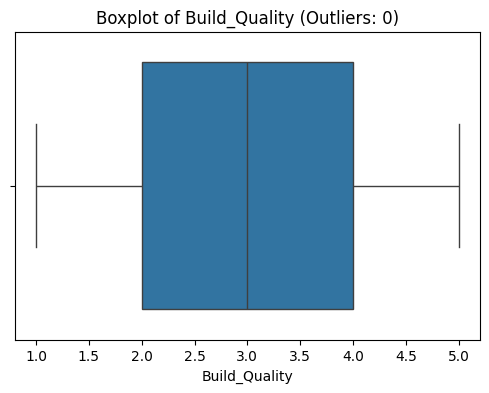

User_Lifespan: 0 outlier(s)


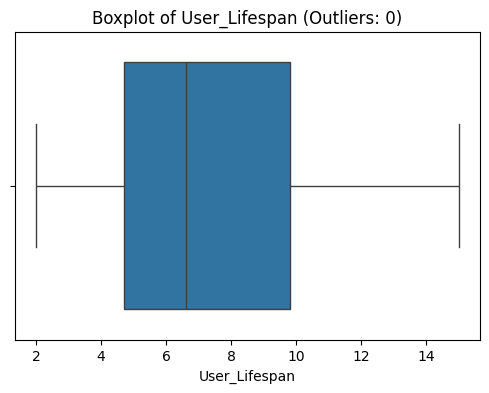

Expiry_Years: 0 outlier(s)


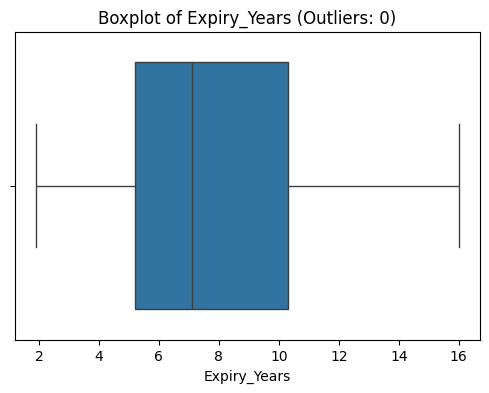

Condition: 0 outlier(s)


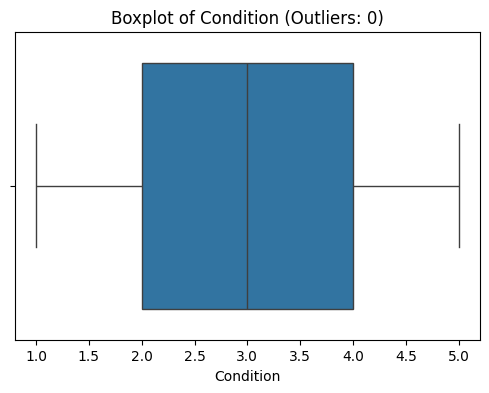

Original_Price: 571 outlier(s)


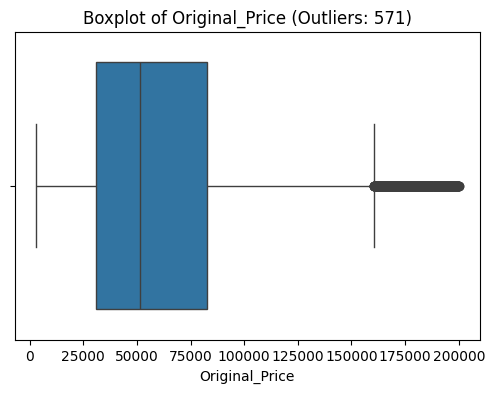

Used_Duration: 0 outlier(s)


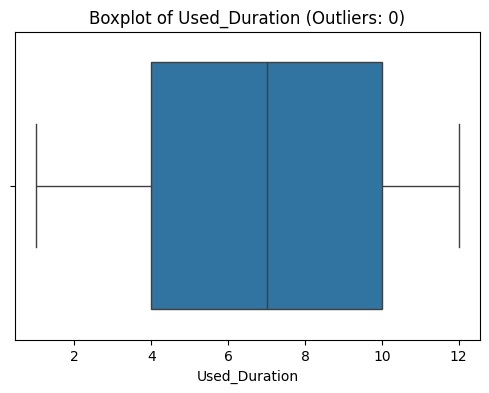

Current_Price: 1137 outlier(s)


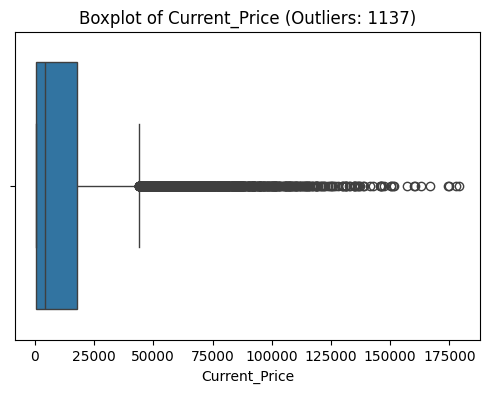

In [43]:
#Checking for outliers

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:", list(numerical_cols))
print("\nOutlier detection using IQR method:")

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Detect outliers
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    num_outliers = outliers.shape[0]
    
    print(f"{col}: {num_outliers} outlier(s)")
    
    # Plot boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Outliers: {num_outliers})')
    plt.show()